In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.utils.class_weight import compute_class_weight
import os

# Data Loading

✅ Train CSV loaded successfully
✅ Test CSV loaded successfully
=== DATA OVERVIEW ===
Training samples: 1101
Test samples: 741

=== DATAFRAME STRUCTURE ===
Train columns: ['id', 'filename', 'label']
Train info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1101 entries, 0 to 1100
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id        1101 non-null   int64 
 1   filename  1101 non-null   object
 2   label     1101 non-null   object
dtypes: int64(1), object(2)
memory usage: 25.9+ KB
None

Train head:
   id                              filename label
0   0  f4da1e77cfbd47e9bf8030e471e0cd58.jpg  Naga
1   1  2390f5dcc0054cbe9100c2a794ea56e2.jpg  Naga
2   2  05b348ac8db74e5ba184a0f51afffee2.jpg  Naga
3   3  5460d1892fab4afdb555d223582105b0.jpg  Naga
4   4  0310279f903845648cf14214f7fbcaf4.jpg  Naga

Test columns: ['id', 'filename']
Test head:
   id                              filename
0   0  929c49c077f242cdb5f69f3638f2b

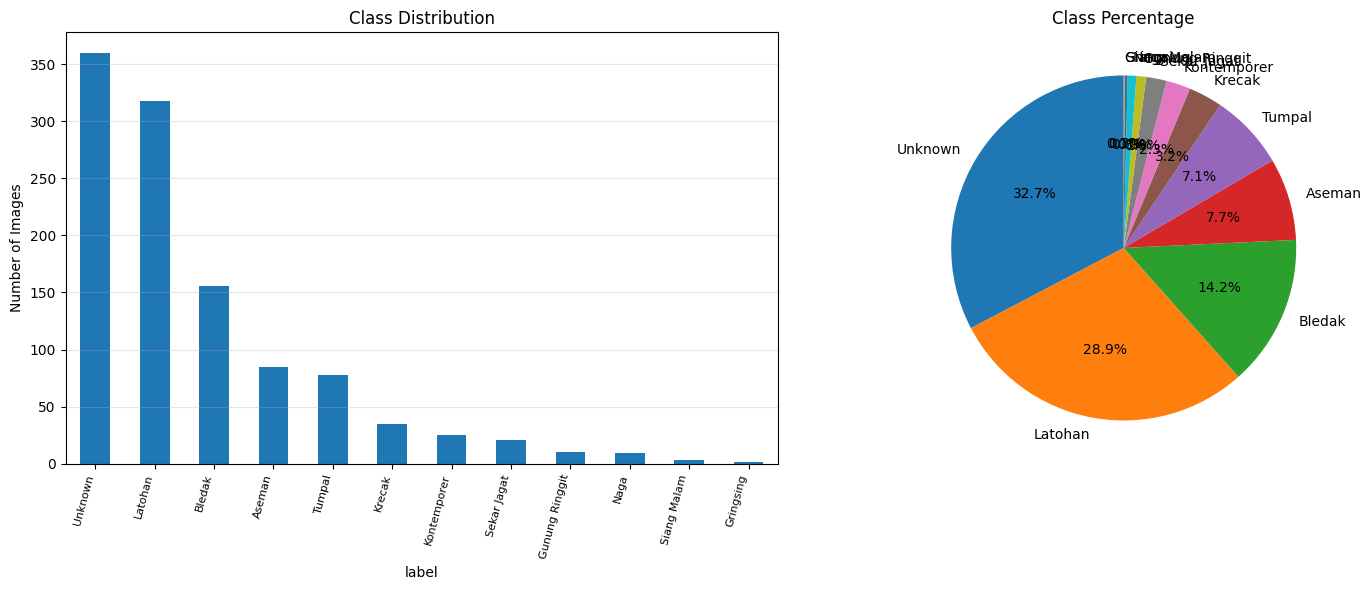


=== CLASS WEIGHTS ===
Aseman: 1.08
Bledak: 0.59
Gringsing: 91.75
Gunung Ringgit: 9.18
Kontemporer: 3.67
Krecak: 2.62
Latohan: 0.29
Naga: 10.19
Sekar Jagat: 4.37
Siang Malam: 30.58
Tumpal: 1.18
Unknown: 0.25

✅ Data check completed successfully!
✅ Class weights calculated for 12 classes


In [8]:
# Data Check&Split

def data_check_and_split():
    """Step 1: Data validation and splitting"""
    
    # Read data with error handling
    try:
        train_df = pd.read_csv('C:/GitHub/untar-deep-learning-course-1-2-gj-2526/train.csv')
        print("✅ Train CSV loaded successfully")
    except FileNotFoundError:
        print(" ⚠️ train.csv not found! Checking directory...")
        # Cek apa yang ada di directory
        base_path = 'C:/GitHub/untar-deep-learning-course-1-2-gj-2526'
        if os.path.exists(base_path):
            files = os.listdir(base_path)
            print("Files in directory:", files)
        return None, None, None
    
    try:
        test_df = pd.read_csv('C:/GitHub/untar-deep-learning-course-1-2-gj-2526/test.csv')
        print("✅ Test CSV loaded successfully")
    except FileNotFoundError:
        print("⚠️ test.csv not found, continuing with train data only")
        test_df = None
    
    print("=== DATA OVERVIEW ===")
    print(f"Training samples: {len(train_df)}")
    print(f"Test samples: {len(test_df) if test_df is not None else 0}")
    
    # Check dataframe structure
    print("\n=== DATAFRAME STRUCTURE ===")
    print("Train columns:", train_df.columns.tolist())
    print("Train info:")
    print(train_df.info())
    print("\nTrain head:")
    print(train_df.head())
    
    if test_df is not None:
        print("\nTest columns:", test_df.columns.tolist())
        print("Test head:")
        print(test_df.head())
    
    # Check class distribution 
    label_column = 'label'
    if label_column not in train_df.columns:
        print(f" Column '{label_column}' not found in train data!")
        print("Available columns:", train_df.columns.tolist())
        # Try to find alternative label column
        possible_labels = [col for col in train_df.columns if 'label' in col.lower() or 'class' in col.lower()]
        if possible_labels:
            label_column = possible_labels[0]
            print(f"Using alternative label column: {label_column}")
        else:
            return train_df, test_df, None
    
    class_counts = train_df[label_column].value_counts()
    print(f"\n=== CLASS DISTRIBUTION ({label_column}) ===")
    print(class_counts)
    
    # Plot class distribution with error handling
    plt.figure(figsize=(15, 6))
    
    # Plot 1: Bar chart
    plt.subplot(1, 2, 1)
    if len(class_counts) > 10:  
        class_counts.plot(kind='bar')
        plt.xticks(rotation=75, ha='right', fontsize=8)
    else:
        class_counts.plot(kind='bar')
        plt.xticks(rotation=45, ha='right')
    plt.title('Class Distribution')
    plt.ylabel('Number of Images')
    plt.grid(axis='y', alpha=0.3)
    
    # Plot 2: Pie chart 
    plt.subplot(1, 2, 2)
    if len(class_counts) <= 15:  # Only show pie chart if not too many classes
        # Truncate long labels for pie chart
        short_labels = [label[:15] + '...' if len(str(label)) > 15 else str(label) for label in class_counts.index]
        plt.pie(class_counts.values, labels=short_labels, autopct='%1.1f%%', startangle=90)
        plt.title('Class Percentage')
    else:
        # If the number of class is too much, show table instead
        plt.axis('off')
        plt.text(0.5, 0.5, f'Too many classes ({len(class_counts)})\nfor pie chart display', 
                ha='center', va='center', transform=plt.gca().transAxes, fontsize=12)
    
    plt.tight_layout()
    plt.show()
    
    # Calculate class weights for imbalance 
    try:
        # Encode labels to numerical values
        unique_labels = np.unique(train_df[label_column])
        label_to_idx = {label: idx for idx, label in enumerate(unique_labels)}
        encoded_labels = train_df[label_column].map(label_to_idx)
        
        class_weights = compute_class_weight(
            'balanced',
            classes=np.unique(encoded_labels),
            y=encoded_labels
        )
        class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}
        
        print("\n=== CLASS WEIGHTS ===")
        for class_idx, weight in class_weight_dict.items():
            class_name = list(label_to_idx.keys())[class_idx]
            print(f"{class_name}: {weight:.2f}")
            
    except Exception as e:
        print(f"⚠️ Error calculating class weights: {e}")
        class_weight_dict = None
    
    return train_df, test_df, class_weight_dict

# Run data check with error handling
try:
    train_df, test_df, class_weights = data_check_and_split()
    
    if train_df is not None:
        print("\n✅ Data check completed successfully!")
        if class_weights is not None:
            print(f"✅ Class weights calculated for {len(class_weights)} classes")
        else:
            print("⚠️  No class weights calculated")
    else:
        print("❌ Failed to load data")
        
except Exception as e:
    print(f" Unexpected error: {e}")
    print("\n NEED TO CHECK! \n")
    print("1. Check if the file path is correct")
    print("2. Check if the CSV file has 'label' column")
    print("3. Check if there are any special characters in the data")

BaseLine Model

In [80]:
import pandas as pd
test_df = pd.read_csv("C:/Users/Elsie/OneDrive/Desktop/DEEPLEARNING/untar-deep-learning-course-1-2-gj-2526/test.csv")
print(test_df.columns)
print(test_df.head())


Index(['id', 'filename'], dtype='object')
   id                              filename
0   0  929c49c077f242cdb5f69f3638f2b59d.jpg
1   1  5d9cc1a8b7624015a0528228f15cedf7.jpg
2   2  1f57bb9f2d3948d49edc86dc3eabe62d.jpg
3   3  382f659a19a842ee9ca325dddad8e6a9.jpg
4   4  2cbe00a446314898bce069fdd162b477.jpg


# Experiment 4

## Train

🚀 INITIALIZING TRAINING WITH EfficientNetV2B0 (Smaller Model)...
📁 Base path: C:\Users\Elsie\OneDrive\Desktop\DEEPLEARNING\untar-deep-learning-course-1-2-gj-2526\data-batik-2025
✅ Found 1101/1101 valid images
Found 881 validated image filenames belonging to 12 classes.
Found 220 validated image filenames belonging to 12 classes.
🎯 Classes found: 12
   Training samples: 881
   Validation samples: 220

Verifikasi Batch Data:
  Bentuk gambar (shape): (16, 224, 224, 3)
  Nilai piksel min: 0.00, max: 255.00
24274472/24274472 ━━━━━━━━━━━━━━━━━━━━ 22s 1us/step

--- 🧠 STAGE 1: FEATURE EXTRACTION (WARM-UP) ---


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_2         │ (None, 224, 224,  │          0 │ input_layer_2[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization_2     │ (None, 224, 224,  │          0 │ rescaling_2[0][0] │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ normalization_2[… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │      4,608 │ stem_activation[… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_bn  │ (None, 112, 112,  │         64 │ block1a_project_… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_ac… │ (None, 112, 112,  │          0 │ block1a_project_… │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_expand_conv │ (None, 56, 56,    │      9,216 │ block1a_project_… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_expand_bn   │ (None, 56, 56,    │        256 │ block2a_expand_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_expand_act… │ (None, 56, 56,    │          0 │ block2a_expand_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_project_co… │ (None, 56, 56,    │      2,048 │ block2a_expand_a… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_project_bn  │ (None, 56, 56,    │        128 │ block2a_project_… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2b_expand_conv │ (None, 56, 56,    │     36,864 │ block2a_project_… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2b_expand_bn   │ (None, 56, 56,    │        512 │ block2b_expand_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2b_expand_act… │ (None, 56, 56,    │          0 │ block2b_expand_b

 Total params: 6,588,508 (25.13 MB)

 Trainable params: 665,612 (2.54 MB)

...

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_2         │ (None, 224, 224,  │          0 │ input_layer_2[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization_2     │ (None, 224, 224,  │          0 │ rescaling_2[0][0] │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ normalization_2[… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │      4,608 │ stem_activation[… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_bn  │ (None, 112, 112,  │         64 │ block1a_project_… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_ac… │ (None, 112, 112,  │          0 │ block1a_project_… │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_expand_conv │ (None, 56, 56,    │      9,216 │ block1a_project_… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_expand_bn   │ (None, 56, 56,    │        256 │ block2a_expand_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_expand_act… │ (None, 56, 56,    │          0 │ block2a_expand_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_project_co… │ (None, 56, 56,    │      2,048 │ block2a_expand_a… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_project_bn  │ (None, 56, 56,    │        128 │ block2a_project_… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2b_expand_conv │ (None, 56, 56,    │     36,864 │ block2a_project_… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2b_expand_bn   │ (None, 56, 56,    │        512 │ block2b_expand_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2b_expand_act… │ (None, 56, 56,    │          0 │ block2b_expand_b

 Total params: 6,588,508 (25.13 MB)

 Trainable params: 2,948,300 (11.25 MB)

 Non-trainable params: 3,640,208 (13.89 MB)

Epoch 20/60
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 884ms/step - accuracy: 0.6215 - loss: 1.4692
Epoch 20: val_accuracy improved from None to 0.40000, saving model to efficientnetB0_batik_best.keras
56/56 ━━━━━━━━━━━━━━━━━━━━ 116s 1s/step - accuracy: 0.6538 - loss: 1.4147 - val_accuracy: 0.4000 - val_loss: 3.0813 - learning_rate: 5.0000e-05
Epoch 21/60
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 959ms/step - accuracy: 0.6616 - loss: 1.4058
Epoch 21: val_accuracy improved from 0.40000 to 0.40455, saving model to efficientnetB0_batik_best.keras
56/56 ━━━━━━━━━━━━━━━━━━━━ 63s 1s/step - accuracy: 0.6731 - loss: 1.3827 - val_accuracy: 0.4045 - val_loss: 3.1366 - learning_rate: 5.0000e-05
Epoch 22/60
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 882ms/step - accuracy: 0.6706 - loss: 1.4034
Epoch 22: val_accuracy did not improve from 0.40455
56/56 ━━━━━━━━━━━━━━━━━━━━ 75s 998ms/step - accuracy: 0.6731 - loss: 1.3713 - val_accuracy: 0.4045 - val_loss: 3.1009 - learning_rate: 5.0000e-05
Epoch 23/60
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 887ms

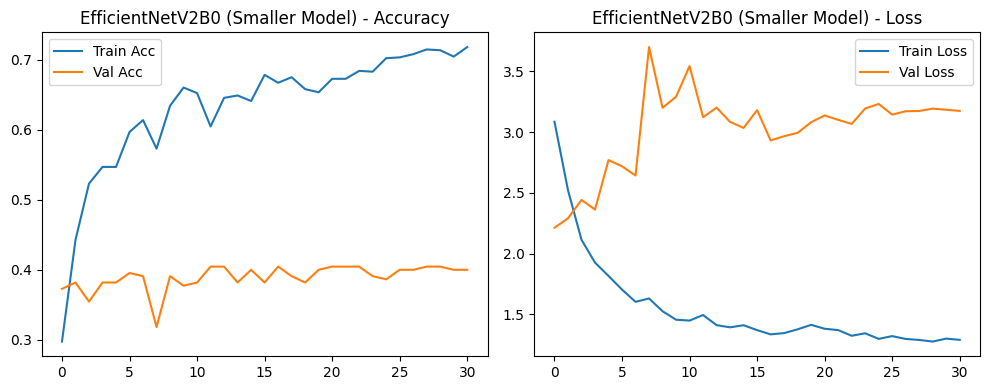

In [ ]:
# EXPERIMENT 4
import os
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# --- IMPORT MODEL BARU (LEBIH KECIL) ---
from tensorflow.keras.applications import EfficientNetV2B0 # <-- GANTI KE B0
# -------------------------

from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import AdamW
from tensorflow.keras.losses import CategoricalCrossentropy
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
import numpy as np

# ======================================================
# PATH FIXER & DATA GENERATOR
# ======================================================
def fix_data_generators(train_df, base_path):
    print(f" Base path: {base_path}")
    label_col = [c for c in train_df.columns if "label" in c.lower() or "class" in c.lower()][0]
    image_col = [c for c in train_df.columns if "file" in c.lower() or "image" in c.lower() or "path" in c.lower()][0]
    train_df[label_col] = train_df[label_col].astype(str).str.strip().str.title()

    def find_path(fname):
        clean = os.path.basename(str(fname))
        for folder in ["train", "images", "data", "dataset", ""]:
            path = os.path.join(base_path, folder, clean)
            if os.path.exists(path):
                return path
        return None

    train_df["full_path"] = train_df[image_col].apply(find_path)
    valid_df = train_df[train_df["full_path"].notna()].copy()
    print(f" Found {len(valid_df)}/{len(train_df)} valid images")

    # --- STRONG AUGMENTATION ---
    train_datagen = ImageDataGenerator(
        # TIDAK ADA rescale=1./255!
        validation_split=0.2,
        rotation_range=25,
        width_shift_range=0.15,
        height_shift_range=0.15,
        zoom_range=0.2,
        shear_range=0.15,
        brightness_range=[0.8, 1.2],
        horizontal_flip=True,
        fill_mode='nearest'
    )

    # Generate Valid Set
    val_datagen = ImageDataGenerator(validation_split=0.2)
    
    # Target Size for B0
    TARGET_SIZE = (224, 224)

    train_gen = train_datagen.flow_from_dataframe(
        valid_df,
        x_col="full_path",
        y_col=label_col,
        target_size=TARGET_SIZE,
        class_mode="categorical",
        batch_size=16,
        subset="training",
        shuffle=True,
        seed=42
    )

    val_gen = val_datagen.flow_from_dataframe(
        valid_df,
        x_col="full_path",
        y_col=label_col,
        target_size=TARGET_SIZE,
        class_mode="categorical",
        batch_size=16,
        subset="validation",
        shuffle=False,
        seed=42
    )
    
    print(f" Classes found: {len(train_gen.class_indices)}")
    print(f" Training samples: {train_gen.samples}")
    print(f" Validation samples: {val_gen.samples}")

    X_batch, y_batch = next(iter(train_gen))
    print(f"\nVerifikasi Batch Data:")
    print(f"  Bentuk gambar (shape): {X_batch.shape}")
    print(f"  Nilai piksel min: {X_batch.min():.2f}, max: {X_batch.max():.2f}") # HARUS [0, 255]
    
    return train_gen, val_gen

# ======================================================
# TRANSFER LEARNING MODEL (EfficientNetV2B0)
# ======================================================
def create_transfer_model(num_classes, input_shape=(224, 224, 3)):
    # --- MODEL B0 ---
    base_model = EfficientNetV2B0(weights='imagenet', include_top=False, input_shape=input_shape)
    base_model.trainable = False 

    # --- TOP MODEL STRONG & REGULARIZED ---
    x = layers.GlobalAveragePooling2D()(base_model.output)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(512, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x) # Dropout 50%
    output = layers.Dense(num_classes, activation='softmax')(x)

    model = tf.keras.Model(inputs=base_model.input, outputs=output)
    return model, base_model

# ======================================================
# TRAIN FUNCTION (2 Phase)
# ======================================================
def train_model(train_df, base_path):
    print(" INITIALIZING TRAINING WITH EfficientNetV2B0 (Smaller Model)...")
    train_gen, val_gen = fix_data_generators(train_df, base_path)
    num_classes = len(train_gen.class_indices)
    
    model, base_model = create_transfer_model(num_classes=num_classes)

    # --- STAGE 1: FEATURE EXTRACTION (WARM-UP HEAD) ---
    print("\n--- STAGE 1: FEATURE EXTRACTION (WARM-UP) ---")
    model.compile(
        optimizer=AdamW(learning_rate=1e-3),
        loss=CategoricalCrossentropy(label_smoothing=0.1),
        metrics=['accuracy']
    )
    model.summary()

    early_stopping = EarlyStopping(monitor='val_accuracy', patience=7, restore_best_weights=True, mode='max', verbose=1)
    
    history_head = model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=30, # Beri 30 epoch untuk warm-up head baru
        callbacks=[early_stopping],
        verbose=1
    )
    
    print("\n STAGE 1 COMPLETE!")
    val_loss_s1, val_acc_s1 = model.evaluate(val_gen, verbose=0)
    print(f" Accuracy after Stage 1: {val_acc_s1:.4f}")

    if val_acc_s1 < 0.3: # Set threshold for tracing the problem, only if we have <30% acc on warmup phase
        print(f" Akurasi Stage 1 ({val_acc_s1:.4f}) sangat rendah. Cek data Anda.")
        return model, history_head, train_gen, val_gen

    # --- STAGE 2: FINE-TUNING ---
    print("\n---  STAGE 2: FINE-TUNING ---")
    
    base_model.trainable = True
    
    for layer in base_model.layers:
        if isinstance(layer, layers.BatchNormalization):
            layer.trainable = False

    fine_tune_at = -60 
    for layer in base_model.layers[:fine_tune_at]:
        layer.trainable = False

    model.compile(
        optimizer=AdamW(learning_rate=5e-5, weight_decay=1e-6), # LR kecil untuk fine-tune
        loss=CategoricalCrossentropy(label_smoothing=0.1),
        metrics=['accuracy']
    )
    model.summary()

    callbacks_ft = [
        EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True, mode='max', verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-7, verbose=1),
        ModelCheckpoint('efficientnetB0_batik_best.keras', monitor='val_accuracy', save_best_only=True, mode='max', verbose=1)
    ]
    
    initial_epoch_ft = len(history_head.history['loss'])

    history_fine_tune = model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=60, # Total epoch lebih banyak
        callbacks=callbacks_ft,
        initial_epoch=initial_epoch_ft,
        verbose=1
    )

    print("\n TRAINING COMPLETE!")
    print(" Loading best weights from efficientnetB0_batik_best.keras...")
    model.load_weights('efficientnetB0_batik_best.keras')
    
    val_loss_final, val_acc_final = model.evaluate(val_gen, verbose=0)
    print(f" Final Validation Accuracy (Best): {val_acc_final:.4f}")
    
    history_combined = combine_histories(history_head, history_fine_tune)
    plot_training_history(history_combined, "EfficientNetV2B0 (Smaller Model)")

    return model, history_combined, train_gen, val_gen

# ======================================================
# VISUALIZATION
# ======================================================

def combine_histories(h1, h2):
    """Menggabungkan dua history training (untuk plot)."""
    history = {}
    for key in h1.history.keys():
        if key in h2.history:
             history[key] = h1.history[key] + h2.history[key]
    return history

def plot_training_history(history, title="Training History"):
    plt.figure(figsize=(10,4))
    
    if 'accuracy' in history:
        plt.subplot(1,2,1)
        plt.plot(history['accuracy'], label='Train Acc')
        plt.plot(history['val_accuracy'], label='Val Acc')
        plt.title(f"{title} - Accuracy")
        plt.legend()
    
    if 'loss' in history:
        plt.subplot(1,2,2)
        plt.plot(history['loss'], label='Train Loss')
        plt.plot(history['val_loss'], label='Val Loss')
        plt.title(f"{title} - Loss")
        plt.legend()
    
    plt.tight_layout()
    plt.show()
    
# ======================================================
# MAIN EXECUTION
# ======================================================
if 'train_df' in globals() and train_df is not None:
    base_path = r"C:\Users\Elsie\OneDrive\Desktop\DEEPLEARNING\untar-deep-learning-course-1-2-gj-2526\data-batik-2025"
    train_model(train_df, base_path) 
else:
    print("train_df not found! Please load your train CSV first.")

🚀 INITIALIZING TRAINING (Custom CNN 'From Scratch')...
📁 Base path: C:\Users\Elsie\OneDrive\Desktop\DEEPLEARNING\untar-deep-learning-course-1-2-gj-2526\data-batik-2025
✅ Found 1101/1101 valid images
Found 881 validated image filenames belonging to 12 classes.
Found 220 validated image filenames belonging to 12 classes.
🎯 Classes found: 12
⚖️ Class Weights Dihitung:
{np.int64(1): np.float64(1.9665178571428572), np.int64(3): np.float64(11.0125), np.int64(5): np.float64(3.1464285714285714), np.int64(6): np.float64(0.3463050314465409), np.int64(8): np.float64(5.244047619047619), np.int64(9): np.float64(36.708333333333336), np.int64(10): np.float64(1.4118589743589745), np.int64(11): np.float64(0.3059027777777778)}

Verifikasi Batch Data:
  Bentuk gambar (shape): (32, 150, 150, 3)
  Nilai piksel min: 0.00, max: 1.00

--- 🧠 Compiling Model 'From Scratch' ---


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 150, 150, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 150, 150, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 150, 150, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 150, 150, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 75, 75, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 75, 75, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 75, 75, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 75, 75, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 37, 37, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 37, 37, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 37, 37, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 37, 37, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 12)             │         1,548 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 290,348 (1.11 MB)

 Trainable params: 289,452 (1.10 MB)

 Non-trainable params: 896 (3.50 KB)

c:\Users\Elsie\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/80
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.1252 - loss: 3.0285
Epoch 1: val_accuracy improved from None to 0.37727, saving model to custom_cnn_batik_best.keras
28/28 ━━━━━━━━━━━━━━━━━━━━ 63s 2s/step - accuracy: 0.1283 - loss: 3.1196 - val_accuracy: 0.3773 - val_loss: 2.3642 - learning_rate: 0.0010
Epoch 2/80
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.1127 - loss: 2.5800
Epoch 2: val_accuracy improved from 0.37727 to 0.45000, saving model to custom_cnn_batik_best.keras
28/28 ━━━━━━━━━━━━━━━━━━━━ 46s 2s/step - accuracy: 0.1146 - loss: 2.7151 - val_accuracy: 0.4500 - val_loss: 2.5411 - learning_rate: 0.0010
Epoch 3/80
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.1769 - loss: 2.3760
Epoch 3: val_accuracy improved from 0.45000 to 0.45455, saving model to custom_cnn_batik_best.keras
28/28 ━━━━━━━━━━━━━━━━━━━━ 56s 2s/step - accuracy: 0.1680 - loss: 2.3203 - val_accuracy: 0.4545 - val_loss: 2.5571 - learning_rate: 0.0010
Epoch 4/80
28/28 ━━━━━━━━━━━━━━━━━━━━

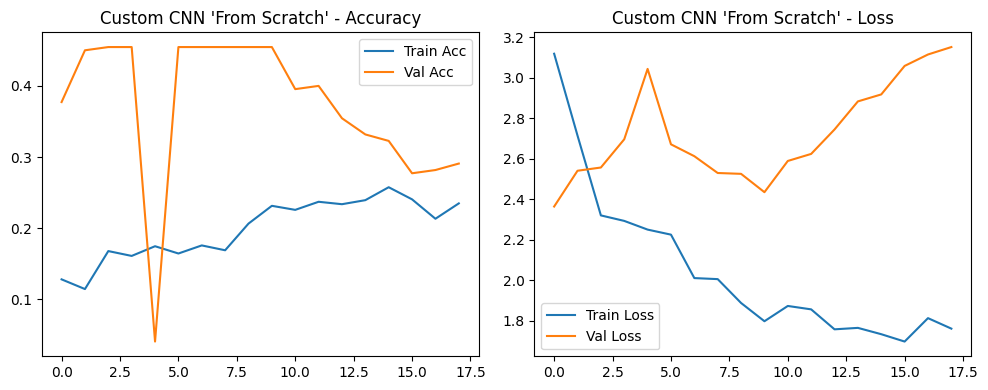

In [14]:
import os
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
# --- TIDAK ADA IMPORT EfficientNet, VGG, dll. KITA BUAT SENDIRI ---
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import AdamW
from tensorflow.keras.losses import CategoricalCrossentropy
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
import numpy as np
from sklearn.utils import class_weight # <-- Tetap kita pakai

# ======================================================
# 🔧 PATH FIXER & DATA GENERATOR
# (PERUBAHAN #1: KEMBALIKAN RESCALE=1./255!)
# ======================================================
def fix_data_generators(train_df, base_path):
    print(f"📁 Base path: {base_path}")
    label_col = [c for c in train_df.columns if "label" in c.lower() or "class" in c.lower()][0]
    image_col = [c for c in train_df.columns if "file" in c.lower() or "image" in c.lower() or "path" in c.lower()][0]
    train_df[label_col] = train_df[label_col].astype(str).str.strip().str.title()

    def find_path(fname):
        clean = os.path.basename(str(fname))
        for folder in ["train", "images", "data", "dataset", ""]:
            path = os.path.join(base_path, folder, clean)
            if os.path.exists(path):
                return path
        return None

    train_df["full_path"] = train_df[image_col].apply(find_path)
    valid_df = train_df[train_df["full_path"].notna()].copy()
    print(f"✅ Found {len(valid_df)}/{len(train_df)} valid images")

    # --- KEMBALIKAN RESCALE & AUGMENTASI KUAT ---
    train_datagen = ImageDataGenerator(
        rescale=1./255, # <-- KRUSIAL: Model kustom BUTUH ini
        validation_split=0.2,
        rotation_range=25,
        width_shift_range=0.15,
        height_shift_range=0.15,
        zoom_range=0.2,
        shear_range=0.15,
        horizontal_flip=True,
        fill_mode='nearest'
    )
    
    # Validation generator juga BUTUH rescale
    val_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)
    
    # Ukuran lebih kecil untuk model "bodoh"
    TARGET_SIZE = (150, 150) # <-- GANTI UKURAN

    train_gen = train_datagen.flow_from_dataframe(
        valid_df,
        x_col="full_path",
        y_col=label_col,
        target_size=TARGET_SIZE,
        class_mode="categorical",
        batch_size=32, # Batch size bisa lebih besar
        subset="training",
        shuffle=True,
        seed=42
    )

    val_gen = val_datagen.flow_from_dataframe(
        valid_df,
        x_col="full_path",
        y_col=label_col,
        target_size=TARGET_SIZE,
        class_mode="categorical",
        batch_size=32,
        subset="validation",
        shuffle=False,
        seed=42
    )
    
    print(f"🎯 Classes found: {len(train_gen.class_indices)}")
    
    # --- PERHITUNGAN CLASS WEIGHT ---
    y_train = train_gen.classes
    class_labels = np.unique(y_train)
    weights = class_weight.compute_class_weight(class_weight='balanced', classes=class_labels, y=y_train)
    class_weights_dict = dict(zip(class_labels, weights))
    print(f"⚖️ Class Weights Dihitung:")
    print(class_weights_dict)
    # ---------------------------------
    
    X_batch, y_batch = next(iter(train_gen))
    print(f"\nVerifikasi Batch Data:")
    print(f"  Bentuk gambar (shape): {X_batch.shape}")
    print(f"  Nilai piksel min: {X_batch.min():.2f}, max: {X_batch.max():.2f}") # <-- HARUS [0, 1] SEKARANG!
    
    return train_gen, val_gen, class_weights_dict

# ======================================================
# 🚀 MODEL KUSTOM "BODOH"
# (PERUBAHAN #2: BUAT MODEL DARI NOL)
# ======================================================
def create_custom_model(num_classes, input_shape=(150, 150, 3)):
    
    model = models.Sequential()
    model.add(layers.Input(shape=input_shape)) # Input layer
    
    # Block 1
    model.add(layers.Conv2D(32, (3, 3), activation='relu', padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.Conv2D(32, (3, 3), activation='relu', padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2, 2)))

    # Block 2
    model.add(layers.Conv2D(64, (3, 3), activation='relu', padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.Conv2D(64, (3, 3), activation='relu', padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2, 2)))

    # Block 3
    model.add(layers.Conv2D(128, (3, 3), activation='relu', padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.Conv2D(128, (3, 3), activation='relu', padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2, 2)))

    # Head
    model.add(layers.GlobalAveragePooling2D())
    model.add(layers.Dropout(0.5)) # Dropout 50% untuk lawan overfit
    model.add(layers.Dense(num_classes, activation='softmax'))

    return model

# ======================================================
# 🧠 FUNGSI TRAINING (STRATEGI 1-TAHAP)
# ======================================================
def train_model(train_df, base_path):
    print("🚀 INITIALIZING TRAINING (Custom CNN 'From Scratch')...")
    
    # Dapatkan class weights dari generator
    train_gen, val_gen, class_weights = fix_data_generators(train_df, base_path)
    num_classes = len(train_gen.class_indices)
    
    model = create_custom_model(num_classes=num_classes)

    # --- HANYA 1x COMPILE ---
    print("\n--- 🧠 Compiling Model 'From Scratch' ---")
    model.compile(
        optimizer=AdamW(learning_rate=1e-3, weight_decay=1e-5), # LR standar
        loss=CategoricalCrossentropy(label_smoothing=0.1),
        metrics=['accuracy']
    )
    model.summary() 

    callbacks = [
        EarlyStopping(monitor='val_accuracy', patience=15, restore_best_weights=True, mode='max', verbose=1), # Kesabaran ekstra
        ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=1e-6, verbose=1), # Kesabaran ekstra
        ModelCheckpoint('custom_cnn_batik_best.keras', monitor='val_accuracy', save_best_only=True, mode='max', verbose=1)
    ]
    
    history = model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=80, # Beri waktu yang panjang (model ini belajar dari nol)
        callbacks=callbacks,
        class_weight=class_weights, # <-- TETAP PAKAI CLASS WEIGHT
        verbose=1
    )
    
    print("\n✅ TRAINING COMPLETE!")
    print("🔄 Loading best weights from custom_cnn_batik_best.keras...")
    model.load_weights('custom_cnn_batik_best.keras')
    
    val_loss_final, val_acc_final = model.evaluate(val_gen, verbose=0)
    print(f"🏆 Final Validation Accuracy (Best): {val_acc_final:.4f}")
    
    plot_training_history(history.history, "Custom CNN 'From Scratch'")

    return model, history, train_gen, val_gen

# ======================================================
# 📊 VISUALIZATION (DENGAN HELPER)
# (Tidak ada perubahan)
# ======================================================

def plot_training_history(history, title="Training History"):
    plt.figure(figsize=(10,4))
    
    if 'accuracy' in history:
        plt.subplot(1,2,1)
        plt.plot(history['accuracy'], label='Train Acc')
        plt.plot(history['val_accuracy'], label='Val Acc')
        plt.title(f"{title} - Accuracy")
        plt.legend()
    
    if 'loss' in history:
        plt.subplot(1,2,2)
        plt.plot(history['loss'], label='Train Loss')
        plt.plot(history['val_loss'], label='Val Loss')
        plt.title(f"{title} - Loss")
        plt.legend()
    
    plt.tight_layout()
    plt.show()
    
# ======================================================
# 🏁 MAIN EXECUTION
# (Tidak ada perubahan)
# ======================================================
if 'train_df' in globals() and train_df is not None:
    base_path = r"C:\Users\Elsie\OneDrive\Desktop\DEEPLEARNING\untar-deep-learning-course-1-2-gj-2526\data-batik-2025"
    train_model(train_df, base_path) 
else:
    print(" train_df not found! Please load your train CSV first.")

## Predict

In [22]:
import os
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import load_model
from tqdm import tqdm

# ======================================================
# SETUP PATH
# ======================================================
base_path = r"C:\Users\Elsie\OneDrive\Desktop\DEEPLEARNING\untar-deep-learning-course-1-2-gj-2526\data-batik-2025"
model_path = r"C:\GitHub\web\DL_Batik-Image-Classification\efficientnetB0_batik_best.keras"

# ======================================================
# LOAD CSV DAN MODEL
# ======================================================
try:
    test_df = pd.read_csv("C:/Users/Elsie/OneDrive/Desktop/DEEPLEARNING/untar-deep-learning-course-1-2-gj-2526/test.csv")
    model = load_model(model_path)
    print(" Model loaded successfully!")
    model.summary() # Tambahan: Lihat arsitektur model
except Exception as e:
    print(f" Error loading model or CSV: {e}")
    exit()

# ======================================================
# FULL PATH TEST SET
# ======================================================
def find_test_path(fname):
    clean = os.path.basename(str(fname))
    # Pastikan untuk mencari di dalam folder test
    for folder in ["test", "images", "data", "dataset", ""]:
        path = os.path.join(base_path, folder, clean)
        if os.path.exists(path):
            return path
    return None

test_df["full_path"] = test_df["filename"].apply(find_test_path)
test_df = test_df[test_df["full_path"].notna()]
print(f" Found {len(test_df)} valid test images")

if len(test_df) == 0:
    raise ValueError("Tidak ada gambar test yang ditemukan. Cek kembali base_path dan nama folder test.")

# ======================================================
# TEST DATA GENERATOR
# ======================================================

# NOTES:
# Model EfficientNet (B0, B1, B2, dll) dari keras.applications

test_datagen = ImageDataGenerator() # <-- WITHOUT RESCALING

TARGET_SIZE_B0 = (224, 224) 

test_gen = test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col="full_path",
    y_col=None, 
    target_size=TARGET_SIZE_B0, # make sure the size suits with the model
    class_mode=None, 
    batch_size=32,   
    shuffle=False    # DONT SHUFFLE, FOLLOW THE INDEX ON TEST FILE
)

# ======================================================
# PREDICTION
# ======================================================
print("Predicting test data...")
pred_probs = model.predict(test_gen, verbose=1)
pred_labels = np.argmax(pred_probs, axis=1)

# ======================================================
# MAPPING LABEL & SETUP FOR EXTRACT TO CSV
# ======================================================
# NOTES: Urutan label ini HARUS SAMA PERSIS dengan urutan yang dipelajari model saat training.

label_map = sorted([
    'Aseman', 'Bledak', 'Gringsing', 'Gunung Ringgit', 'Kontemporer', 'Krecak',
    'Latohan', 'Naga', 'Sekar Jagat', 'Siang Malam', 'Tumpal', 'Unknown'
])

# Check Number of Class
if len(label_map) != model.output_shape[-1]:
    print(f" Warning: Jumlah kelas model ({model.output_shape[-1]}) tidak sama dengan label_map ({len(label_map)})!")
else:
    print(" Label map and model output shape match.")

# Take class name based on the index
pred_class_names = [label_map[i] for i in pred_labels]

# Create DataFrame for submission
submission = pd.DataFrame({
    "id": test_df["id"],
    "label": pred_class_names
})

# Save to CSV
submission.to_csv("submission4.csv", index=False)
print("\n Predictions saved to submission4.csv")
print("Submission file head:")
print(submission.head())

✅ Model loaded successfully!


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_2         │ (None, 224, 224,  │          0 │ input_layer_2[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization_2     │ (None, 224, 224,  │          0 │ rescaling_2[0][0] │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ normalization_2[… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │      4,608 │ stem_activation[… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_bn  │ (None, 112, 112,  │         64 │ block1a_project_… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_ac… │ (None, 112, 112,  │          0 │ block1a_project_… │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_expand_conv │ (None, 56, 56,    │      9,216 │ block1a_project_… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_expand_bn   │ (None, 56, 56,    │        256 │ block2a_expand_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_expand_act… │ (None, 56, 56,    │          0 │ block2a_expand_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_project_co… │ (None, 56, 56,    │      2,048 │ block2a_expand_a… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_project_bn  │ (None, 56, 56,    │        128 │ block2a_project_… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2b_expand_conv │ (None, 56, 56,    │     36,864 │ block2a_project_… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2b_expand_bn   │ (None, 56, 56,    │        512 │ block2b_expand_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2b_expand_act… │ (None, 56, 56,    │          0 │ block2b_expand_b

 Total params: 12,485,110 (47.63 MB)

 Trainable params: 2,948,300 (11.25 MB)

 Non-trainable params: 3,640,208 (13.89 MB)

 Optimizer params: 5,896,602 (22.49 MB)

✅ Found 741 valid test images
Found 741 validated image filenames.
🚀 Predicting test data...


c:\Users\Elsie\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


24/24 ━━━━━━━━━━━━━━━━━━━━ 12s 438ms/step
✅ Label map and model output shape match.

✅ Predictions saved to submission4.csv
Submission file head:
   id    label
0   0   Bledak
1   1  Unknown
2   2  Latohan
3   3  Latohan
4   4  Unknown
